In [3]:
#pip install matplotlib

     ---------------------------------------- 0.0/165.9 kB ? eta -:--:--
     ------------------------- ------------ 112.6/165.9 kB 3.3 MB/s eta 0:00:01
     -------------------------------------- 165.9/165.9 kB 3.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
   -- ------------------------------------- 0.4/7.8 MB 12.9 MB/s eta 0:00:01
   ---- ----------------------------------- 0.9/7.8 MB 14.5 MB/s eta 0:00:01
   ------- -------------------------------- 1.6/7.8 MB 14.2 MB/s eta 0:00:01
   ------------ --------------------------- 2.4/7.8 MB 16.9 MB/s eta 0:00:01
   ----------------- ---------------------- 3.4/7.8 MB 19.8 MB/s eta 0:00:01
   ----------------------- ---------------- 4.6/7.8 MB 22.9 MB/s eta 0:00:01
   ------------------------------- -------- 6.2/7.8 MB 24.9 MB/s eta 0:00:01
   ---------------------------------------  7.8/7.8 MB 27.8 MB/s eta 0:00:01
   ---------------------------------------- 7.8/7.8 MB 27.8 MB/s eta 0:00:00
   --


[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# 데이터 경로 설정
data_dir = r'D:\2024신한해커톤\음식 섭취 추정 프로젝트\Data' 

# 데이터 준비
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    data_dir,  # 'Before'와 'After' 하위 폴더로 구분되어 있어야 합니다.
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='training'  # Training set
)

validation_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='validation'  # Validation set
)

# 모델 정의
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # 이진 분류를 위해 sigmoid 활성화 함수 사용
])

# 모델 컴파일
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 모델 학습
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=50
)

# 모델 평가
loss, accuracy = model.evaluate(validation_generator)
print(f'Validation Loss: {loss}')
print(f'Validation Accuracy: {accuracy}')

Found 916 images belonging to 2 classes.
Found 228 images belonging to 2 classes.


d:\Python\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50


d:\Python\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 347ms/step - accuracy: 0.5614 - loss: 1.1489 - val_accuracy: 0.5179 - val_loss: 0.7235
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8438 - loss: 0.5343 - val_accuracy: 0.5000 - val_loss: 0.6790
Epoch 3/50


d:\Python\Lib\contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(value)


28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 243ms/step - accuracy: 0.7025 - loss: 0.5790 - val_accuracy: 0.7098 - val_loss: 0.5739
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 743us/step - accuracy: 0.9062 - loss: 0.3396 - val_accuracy: 1.0000 - val_loss: 0.3841
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 241ms/step - accuracy: 0.8693 - loss: 0.3018 - val_accuracy: 0.6741 - val_loss: 0.8215
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 913us/step - accuracy: 1.0000 - loss: 0.1510 - val_accuracy: 0.5000 - val_loss: 0.5401
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 253ms/step - accuracy: 0.9312 - loss: 0.1853 - val_accuracy: 0.6875 - val_loss: 0.8901
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 704us/step - accuracy: 1.0000 - loss: 0.0529 - val_accuracy: 0.7500 - val_loss: 0.3731
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 241ms/step - accuracy: 0.9856 - loss: 0.0644 - val_accuracy: 0.6830 - val_loss: 1.2183
Epoch 10/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step - accuracy: 1.0000 - loss: 0.0119 - val_accuracy: 0.2500 - val

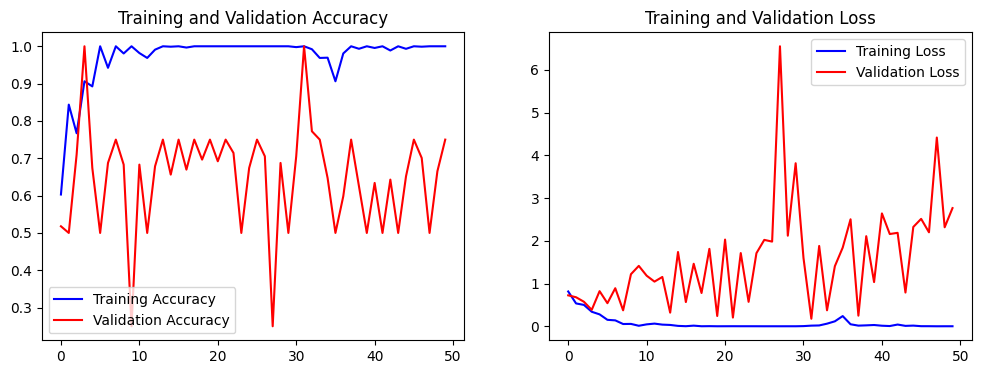

In [4]:
import matplotlib.pyplot as plt

# 학습 과정에서의 accuracy와 loss를 기록한 history를 이용해 시각화
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

# 정확도 시각화
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# 손실 시각화
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()

In [9]:
from tensorflow.keras.preprocessing import image
import numpy as np

# 예측할 이미지 경로
img_path = r'D:\2024신한해커톤\음식 섭취 추정 프로젝트\TestImage\example.jpg'

# 이미지를 모델에 넣기 위한 전처리
img = image.load_img(img_path, target_size=(150, 150))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # 배치 크기 추가
img_array /= 255.0  # 모델이 학습된 대로 이미지 스케일 조정

# 이미지 예측
prediction = model.predict(img_array)

# 예측 결과 출력
if prediction[0] > 0.5:
    print(f'예측 상태는 Before이고, 예측값은 {prediction[0][0]:.2f} 입니다.')
else:
    print(f'예측 상태는 After이고, 예측값은 {1 - prediction[0][0]:.2f} 입니다.')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
The model predicts this is "Before" with a probability of 0.82
